# Introduction


**File:** Notebook_to_build_graphics.ipynb 
\
**Author:** Elizabeth Gould
\
**Date:** 10.03.2026
\
**Problem:** Here there are two:
 1) Plot $\psi(x)$
 2) Test our model for $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$

This code contains two short exercises. The first is just a sample of a run of our derivative grid code, which plots the IVP solutions for $\psi(x)$ The second is a short Monte Carlo test of our model for $M_{\mu}\left(BR, dk, \mu, \psi_0^\prime\right)$, which contains both visual and numerical analysis.

# Derivative Grids

This is the code used for building the derivative grid graphs with the deriv_grid class of my library.

In [ ]:
#--LIBRARIES--------

#numerics
import numpy as np
import eelib

#--CODE--

# set parameters
# note that k, B, and R are percents here, mu is not as its scale is unknown
k = 0.625
R = 0.8
B = 0.5
mu = 1.0e-7

n_g = 4

pr = 1000
n = 2

loopl = eelib.deriv_grid(R, B, k, mu, grid_size=n_g)
loopl.derivGrid()


# --- PLOTTING FOR GRIDS ---
for i in range(n_g):
    for j in range(n_g):
        loopl.plot_abs(i,j,k,R,B,mu,n)
        loopl.plot_real(i,j,k,R,B,mu,n)

# Test of Slow Oscillation Wavenumber Model

This is code to visually and numerically test the fit of my slow oscillation model. The model is not perfect, but good enough.

In [1]:
import eelib
import numpy as np
import matplotlib.pyplot as plt
import sklearn.metrics as mtc
from sklearn.metrics import root_mean_squared_error

In [2]:
#--PARAMETERS--------

# note that k, B, and R are percents here, mu is not as its scale is unknown
dk = 0.5
R  = 1.0
B  = 0.5
mu = 1.0e-6

n_mc = 200

b_r  = (0.5, 1.0)  # B here is B*R
mu_r = (-8, -6)    # 1.0e-8 to 1.0e-6
k_r = (0.1,0.9)


In [3]:
rms_ratio_graph = np.sqrt(1000) / np.sqrt(999)
rms_ratio_fin = np.sqrt(n_mc)/ np.sqrt(n_mc - 1)

In [4]:
#--CODE--

# Make the grid object
gridl = eelib.grid_slow_osc(R, B, dk, mu)

# Save our full solution
gridl.save_solution = True

# Make the grid
gridl.makeMCPoints(mu=mu_r, dk=k_r, B=b_r, num = n_mc)

# Run the grid
gridl.mcSlowOsc()

Begin grid build:  0.0
Number of periods to calculate: 200
Done grid build:  26503.432553768158


In [5]:
import pickle
filename = 'grid200'

# Since this takes a while to run and is used for a while, it is best to save a copy of the data.
file = open(filename, 'ab')
pickle.dump(gridl, file)
file.close()

In [6]:
# First, declare which solution I am using
ii  = int(np.random.rand()*n_mc)
#if ii >= n_mc: ii = n_mc - 1 # just in case
sol = gridl.slow_osc_sol[ii]
#sol1 = gridl.slow_osc_sol_1[ii]

# Retrieve my fits for this function from the grid.
MM    = gridl.slow_osc_k[ii]
amp   = gridl.slow_osc_a[ii]
theta = gridl.slow_osc_th[ii]

# Predicted slow oscillation amplitude.
vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

# Pull the found solution from the sol variable.
t_list  = sol['t'][:-1]
y1_list = np.real(sol['y'][0][:-1])

# Estimated fit
y2_list = amp * np.sin(MM2 * (t_list) + theta)

# Fit to a sin using SciPy
y3_list = amp * np.sin(MM * t_list + theta)

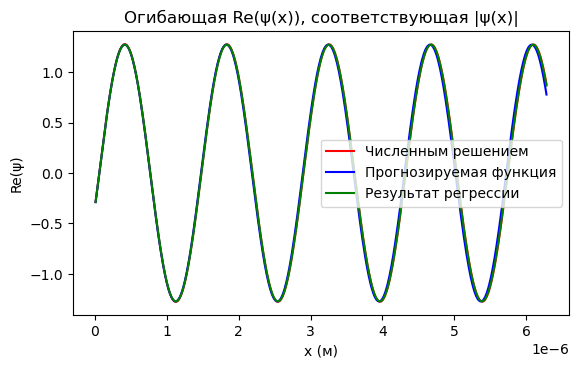

In [9]:
# And plot the results
fig, ax = plt.subplots()

ax.set_ylabel('Re(ψ)')
ax.set_xlabel('x (м)')
plt.title(f"Огибающая Re(ψ(x)), соответствующая |ψ(x)|")

line1, = ax.plot(t_list, y1_list, color = 'red', label = 'Численным решением')
line2, = ax.plot(t_list, y2_list, color = 'blue', label = 'Прогнозируемая функция')
line3, = ax.plot(t_list, y3_list, color = 'green', label = 'Результат регрессии')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.savefig("matchMivp007.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [16]:
print(root_mean_squared_error(y1_list, y2_list)/np.max(np.abs(y1_list)))
print(root_mean_squared_error(y1_list, y3_list)/np.max(np.abs(y1_list)))
print(root_mean_squared_error(y2_list, y3_list)/np.max(np.abs(y1_list)))

0.03993516881736234
0.00493627968824719
0.035947773887384564


In [11]:
print(mtc.mean_absolute_percentage_error(y1_list, y2_list))
print(mtc.mean_absolute_percentage_error(y1_list, y3_list))
print(mtc.mean_absolute_percentage_error(y2_list, y3_list))

0.17830186629175684
0.02284928134954574
0.20395909866803796


In [12]:
print(mtc.r2_score(y1_list, y2_list))
print(mtc.r2_score(y1_list, y3_list))
print(mtc.r2_score(y2_list, y3_list))
#print(mtc.mean_absolute_percentage_error(y1_list, y2_list))
#print(mtc.mean_absolute_percentage_error(y1_list, y3_list))
#print(mtc.mean_absolute_percentage_error(y2_list, y3_list))

0.9968081197107392
0.999951231986785
0.9973963359730292


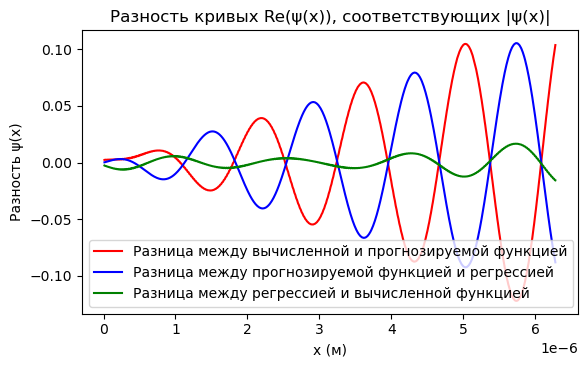

In [13]:
# Plot differences
fig, ax = plt.subplots()

ax.set_ylabel('Разность ψ(x)')
ax.set_xlabel('x (м)')
plt.title(f"Разность кривых Re(ψ(x)), соответствующих |ψ(x)|")

line1, = ax.plot(t_list, y1_list-y2_list, color = 'red', label = 'Разница между вычисленной и прогнозируемой функцией')
line2, = ax.plot(t_list, y2_list-y3_list, color = 'blue', label = 'Разница между прогнозируемой функцией и регрессией')
line3, = ax.plot(t_list, y3_list-y1_list, color = 'green', label = 'Разница между регрессией и вычисленной функцией')

ax.legend(handles=[line1,line2,line3])
ax.set_box_aspect(2.0/3.5)

plt.savefig("matchMivp008.pdf", format = "pdf", bbox_inches = "tight", pad_inches=0)

In [15]:
np.abs(gridl.slow_osc_sol_1[ii]-gridl.slow_osc_sol[ii]['y'][0][-1])

0.12836432400559925

In [7]:
gridl.slow_osc_sol_1

[(-0.8110910869263062+1.292487141256729j)]

In [8]:
gridl.l_calc.psij_pred(2*eelib.pi*R*10**(-6))

(-0.8110910869263062+1.292487141256729j)

In [20]:
res = []
for i in range(n_mc):
    res.append(gridl.slow_osc_sol[i]['y'][0][-1])

In [17]:
# Print the differences
print(f"Estimated slow oscillation wave number: {MM2}")
print(f"Fit slow oscillation wave number: {MM}")
print("Maximum difference between regression fit and predicted fit:", np.max(y3_list-y2_list))
print("Maximum difference between numerical solution and predicted fit:", np.max(y1_list-y2_list))
print("Maximum difference between numerical solution and regression fit:", np.max(y1_list-y3_list))

Estimated slow oscillation wave number: 4443449.347024012
Fit slow oscillation wave number: 4429003.125880681
Maximum difference between regression fit and predicted fit: 0.09242228835626405
Maximum difference between numerical solution and predicted fit: 0.10475241293517426
Maximum difference between numerical solution and regression fit: 0.0156756201895607


In [64]:
# Now for the rest of the numbers
max_arr = np.zeros((n_mc,3))
ave_arr = np.zeros((n_mc,3))
std_arr = np.zeros((n_mc,3))
rmse_arr = np.zeros((n_mc,3))
mape_arr = np.zeros((n_mc,3))
r2_arr = np.zeros((n_mc,3))
arr_wn = np.zeros((n_mc,2))
arr_fp = np.zeros((n_mc,2), dtype="complex")
arr_max = np.zeros(n_mc)
for ii in range(n_mc):
    # First, declare which solution I am using
    sol = gridl.slow_osc_sol[ii]

    # Retrieve my fits for this function from the grid.
    MM    = gridl.slow_osc_k[ii]
    amp   = gridl.slow_osc_a[ii]
    theta = gridl.slow_osc_th[ii]

    # Predicted slow oscillation amplitude.
    vt = gridl.val_table[ii] # mu, dk, B, R, A, k0, dr, di
    MM2 = eelib.pred_slow_k(vt[6]+1j*vt[7], vt[0], vt[0], vt[2]*eelib.B_max, vt[3]*eelib.R_max, vt[4], vt[5]) #dpsi0, mu, dk, B, R, A = 1., k0=kFAu

    arr_wn[ii] = [MM, MM2]

    # Pull the found solution from the sol variable.
    t_list  = sol['t'][:-1]
    y1_list = np.real(sol['y'][0][:-1])

    # Estimated fit
    y2_list = amp * np.sin(MM2 * (t_list) + theta)

    # Fit to a sin using SciPy
    y3_list = amp * np.sin(MM * t_list + theta)

    y_end = sol['y'][0][-1]
    arr_fp[ii] = [y_end, gridl.slow_osc_sol_1[ii]]
    arr_max[ii] = np.max(np.abs(y1_list))

    max_arr[ii, :] = [np.max(np.abs(y3_list-y2_list)), np.max(np.abs(y1_list-y2_list)), np.max(np.abs(y1_list-y3_list))]
    ave_arr[ii, :] = [np.average(y3_list-y2_list), np.average(y1_list-y2_list), np.average(y1_list-y3_list)]
    std_arr[ii, :] = [np.std(y3_list-y2_list), np.std(y1_list-y2_list), np.std(y1_list-y3_list)]
    rmse_arr[ii, :] = [mtc.root_mean_squared_error(y3_list,y2_list)/np.max(np.abs(y1_list)), mtc.root_mean_squared_error(y1_list,y2_list)/np.max(np.abs(y1_list)), mtc.root_mean_squared_error(y1_list,y3_list)/np.max(np.abs(y1_list))]
    mape_arr[ii, :] = [mtc.mean_absolute_percentage_error(y3_list,y2_list), mtc.mean_absolute_percentage_error(y1_list,y2_list), mtc.mean_absolute_percentage_error(y1_list,y3_list)]
    r2_arr[ii, :] = [mtc.r2_score(y3_list,y2_list), mtc.r2_score(y1_list,y2_list), mtc.r2_score(y1_list,y3_list)]

    # Print the differences
    print(f"Random solution {ii}")
    print(f"Estimated slow oscillation wave number: {MM2}")
    print(f"Fit slow oscillation wave number: {MM}")
    print("Maximum difference between regression fit and estimated fit:", max_arr[ii,0])
    print("Maximum difference between numerical solution and estimated fit:", max_arr[ii,1])
    print("Maximum difference between numerical solution and regression fit:", max_arr[ii,2])
    print("Average Diff: ", ave_arr[ii,:])
    print("Std: ", std_arr[ii,:])
    print("rmse: ", rmse_arr[ii,:])
    print("mape: ", mape_arr[ii,:])

    print("")

Random solution 0
Estimated slow oscillation wave number: 8934474.230665008
Fit slow oscillation wave number: 8949690.427015891
Maximum difference between regression fit and estimated fit: 0.13111838700629228
Maximum difference between numerical solution and estimated fit: 0.13676669126987256
Maximum difference between numerical solution and regression fit: 0.007523158701381094
Average Diff:  [ 1.74788107e-03  1.72256203e-03 -2.53190442e-05]
Std:  [0.05511527 0.05569327 0.00200226]
rmse:  [0.03850067 0.03890347 0.00139808]
mape:  [0.2197971  0.21288507 0.00584363]

Random solution 1
Estimated slow oscillation wave number: 8796236.980165362
Fit slow oscillation wave number: 8789997.685184462
Maximum difference between regression fit and estimated fit: 0.060157900727594985
Maximum difference between numerical solution and estimated fit: 0.060913337677933936
Maximum difference between numerical solution and regression fit: 0.003414638069772824
Average Diff:  [-3.23218186e-05  8.09473886e-

In [63]:
np.sqrt(np.average(np.power(rmse_arr[:,1]/arr_max, 2))*(1000*200)/(1000*200-1))

0.019322203656266936

In [65]:
np.min(r2_arr[:,1])

0.9778744786447756

In [66]:
np.average(r2_arr[:,1])

0.9987016473051271

In [51]:
print(np.max(max_arr[:,0]), np.max(mape_arr[:,0]), np.max(rmse_arr[:,0]))

0.2909050167700874 35.94351986098972 0.08358119147242464


In [53]:
np.sqrt(np.average(np.power(rmse_arr[:,1], 2)))

0.025396819000830604

In [54]:
np.average(mape_arr[:,0])

0.3651131851677771

In [52]:
print(np.max(max_arr[:,1]), np.max(mape_arr[:,1]), np.max(rmse_arr[:,1]))

0.25859380780808283 13.212243782602457 0.1049203645755482


In [27]:
print(np.average(max_arr[:,1]), np.average(mape_arr[:,1]), np.average(rmse_arr[:,1]))

0.06485278391976665 0.322866662333772 0.02018920799825867


In [28]:
print(np.average(max_arr[:,0]), np.average(mape_arr[:,0]), np.average(rmse_arr[:,0]))

0.06440888691637077 0.3651131851677771 0.019752315563777628


In [29]:
np.sqrt(np.average(np.power(rmse_arr[:,1], 2))), np.sqrt(np.sum(np.power(rmse_arr[:,1], 2))/199)

(0.025396819000830604, 0.025460550139933955)

In [30]:
mtc.root_mean_squared_error(arr_wn[:,0], arr_wn[:,1])

9532.675792540274

In [48]:
mtc.mean_absolute_percentage_error(arr_wn[:,0], arr_wn[:,1])

0.001115057174741308

In [71]:
np.max(np.abs((arr_wn[:,0]-arr_wn[:,1]))), np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0], 2)))#*np.sqrt(200)/np.sqrt(199)

(31902.970783033874, 0.001503941286166775)

In [39]:
np.sqrt(np.average(np.power((arr_wn[:,0]-arr_wn[:,1]), 2)))

9532.675792540274

In [67]:
np.max((arr_wn[:,0]-arr_wn[:,1])/arr_wn[:,0])

0.007986582830737807

In [ ]:
mtc.r2_score(arr_wn[:,0], arr_wn[:,1])

0.9999652664415529

In [49]:
np.mean(arr_wn[:,0]-arr_wn[:,1]), np.std(arr_wn[:,0]-arr_wn[:,1])

(269.10477837236135, 9528.876659078996)

In [21]:
arr_fp[:,0]

array([ 1.21718003+0.5224182j , -0.1530997 -1.3287765j ,
       -0.22628065-0.25246051j,  1.21035406-0.29557245j,
       -0.71770207-1.00934195j,  0.0416293 -0.73453938j,
       -0.61741936+0.49424626j,  0.43349268+0.04565955j,
       -0.17337954-0.93307543j, -0.03232809-0.68974642j,
       -0.87619097+1.36848972j,  0.95873621+0.01528583j,
       -1.26571169-0.43250507j,  0.52854243+1.18699592j,
       -0.62670304-0.76885775j,  0.07062713+0.09594663j,
        0.71267293-0.20902895j, -0.38711274+0.04367629j,
       -0.17651231+0.19311168j, -0.92770653+1.25120428j,
       -0.31184673+0.19223112j, -1.33216676-0.10616198j,
       -0.14700719+0.4088839j ,  0.21986033-0.99504671j,
       -0.4398596 -0.38766793j, -0.13764054+0.4616402j ,
        0.68841524-0.6202406j ,  1.29093595-0.4786363j ,
        0.97353505-0.18584411j,  0.37340175+0.93490405j,
       -0.83240541-0.08053344j,  0.11070328+0.12771485j,
       -0.91164732-0.07912801j, -1.00965992-0.17759942j,
       -0.76463872-0.38730173j,

In [36]:
np.sqrt(np.sum(np.power(np.abs(arr_fp[:,0]-arr_fp[:,1]), 2))/199)

0.09248722367024224

In [34]:
np.max(np.abs(arr_fp[:,0]-arr_fp[:,1]))

0.2457363632692846

In [38]:
np.std(arr_fp[:,0]-arr_fp[:,1])

0.0921828337310655